# X-ray Light Curve Simulation
This tutorial validates the `qpenn` package by simulating a quasi-periodic eruption. 
We will:
1. Generate the 2D dynamic specific luminosity $L_E(E, t)$ using the EMRI accretion disk model.
2. Visualize the spectral cooling of the gas cloud during the eruptions.
3. Fold the theoretical emission through a standard NICER effective area curve (ARF) to simulate expected photon count rates and Poisson errors.

We use the physical light curve model of [Franchini et al. (2023)](https://arxiv.org/pdf/2304.00775) (without disk precession).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from qpenn import Luminosity, DetectorFold, fetch_arf

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

In [3]:
# Ensure the NICER Ancillary Response File (for detector count-rate) is available.
arf_path = fetch_arf("NICER_simulation")

Found local ARF for 'NICER_simulation': /media/shubham/Ubuntu-HDD/College/PhD/Projects/QPE-MLmodel/QPENN/examples/../downloads/nixtiaveonaxis20170601v005.arf


In [4]:
# 1. Initialize the Simulation Grids
tmax_sec = 36 * 3600    # total duration in seconds
dt_sec = 100.0          # time steps in seconds

# Initialize the luminosity model over the 0.2-2.0 keV band
lum_model = Luminosity(
    tmax=tmax_sec,
    dt=dt_sec,
    e_min_kev=0.2,
    e_max_kev=2.0,
    nE=200 #number of energy bins
)

print(f"Grid initialized: {lum_model.nT} time steps, {lum_model.nE} energy bins.")

Grid initialized: 1296 time steps, 200 energy bins.


In [7]:
# 2. Run the EMRI QPE light-curve simulation

ecc = 0.3
a_semi = 150.0
p_semi = a_semi * (1.0 - ecc**2)
inc_deg = 15.0 

print("Computing orbital dynamics and 2D specific luminosity grid...")

L_E_matrix = lum_model(
    a = 0.9,            #primary spin
    p = p_semi,         #semi-latus rectum
    e = ecc,            #eccentricity
    inc_deg = 15.0,     #inclination (degrees)
    m1 = 1e6,           #primary mass
    m2 = 100.0,         #secondary mass
    m1dot = 0.04,       #Eddington-scaled mass accretion rate
    f = 3.01,           #disk mass (solar masses)
    Delta_t = 3600.0,   #flare expansion timescale
    pli = 1.75,         #surface-density power-law index
    eta = 0.1,          #accretion efficiency
    Rout = 300.0,       #outer radius of the disk in geometric units
)

print("Luminosity grid calculation complete.")

Computing orbital dynamics and 2D specific luminosity grid...
Luminosity grid calculation complete.


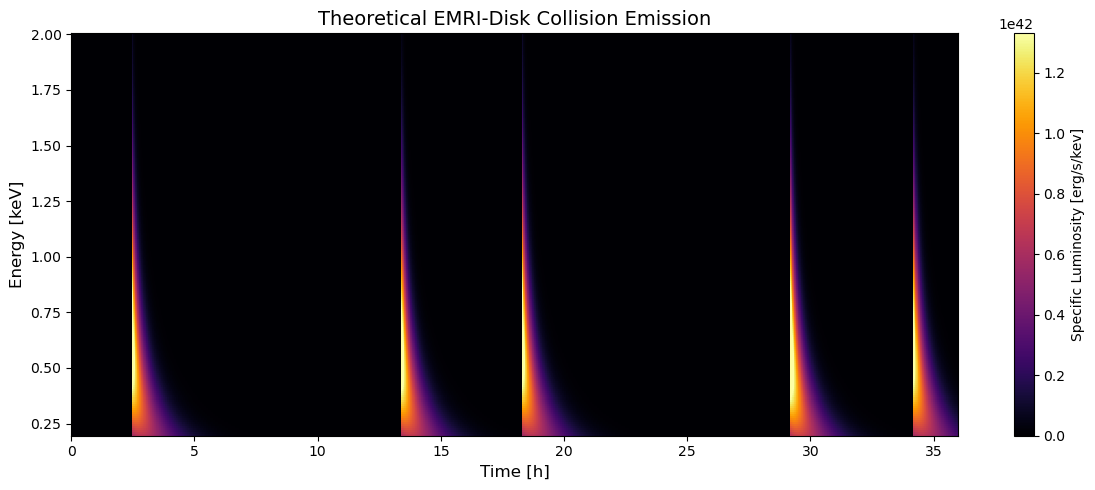

In [8]:
# 3. Visualize the 2D specific luminosity (E, t)

time_hours = lum_model.t_grid / 3600.0

plt.figure(figsize=(12,5))
c = plt.pcolormesh(
    time_hours,
    lum_model.e_grid_kev,
    L_E_matrix,
    shading='auto',
    cmap='inferno',
    vmax=np.max(L_E_matrix) * 0.8 #cap color scale to highlight structure.
)

plt.colorbar(c, label='Specific Luminosity [erg/s/kev]')
plt.title('Theoretical EMRI-Disk Collision Emission', fontsize=14)
plt.xlabel('Time [h]', fontsize=12)
plt.ylabel('Energy [keV]', fontsize=12)
plt.xlim(0, tmax_sec/3600)
plt.tight_layout()
plt.show()

In [9]:
# 4. Fold through the NICER detector using simulated ARF

# Initialize the detector using NICER ARF and energy grid
nicer_detector = DetectorFold(arf_path, lum_model.e_grid_kev)

# Define the luminosity distance using redshift and standard cosmology
z = 0.01
D_L_mpc = cosmo.luminosity_distance(z) #assuming Planck18 cosmology
D_L_cm = D_L_mpc.to(u.cm).value

print(f"Calculated Luminosity Distance: {D_L_cm:.2e} cm")

# Calculate the expected count rates and Poisson errors
count_rate, rate_errors = nicer_detector.calculate_rates_and_errors(
    L_E_2d=L_E_matrix,
    distance_cm=D_L_cm,
    dt=dt_sec,
    bg_rate=1.0
)

Calculated Luminosity Distance: 1.38e+26 cm


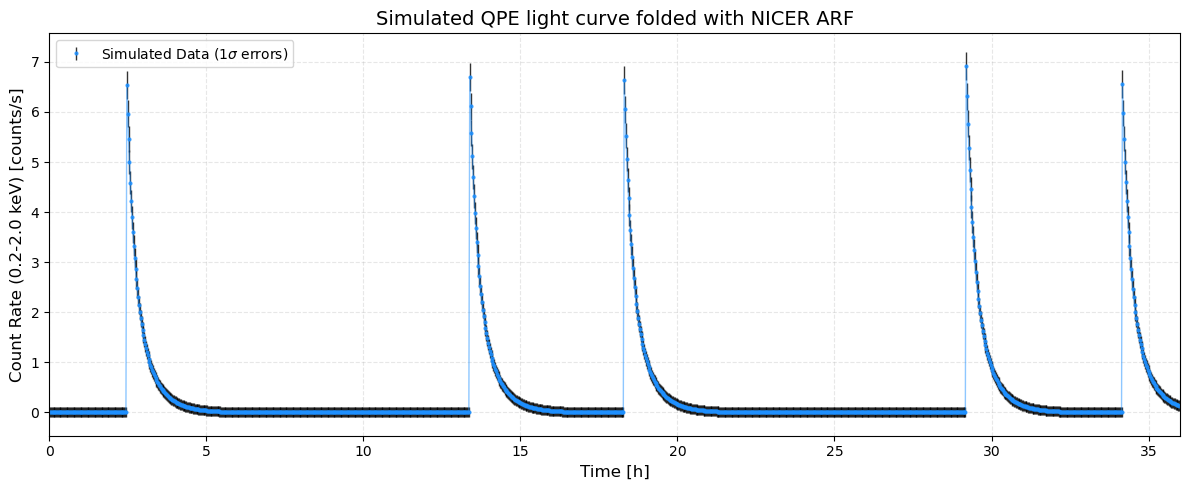

In [10]:
# 5. Plot the simulated light curve

plt.figure(figsize=(12,5))

# Plot the folded count rate with Poisson error bars
plt.errorbar(
    time_hours,
    count_rate,
    yerr=rate_errors,
    fmt='.',
    markersize=4,
    color='dodgerblue',
    ecolor='k',
    elinewidth=1,
    capsize=0,
    alpha=0.8,
    label=r'Simulated Data (1$\sigma$ errors)'
)

plt.plot(time_hours, count_rate, color='dodgerblue', linewidth=1, alpha=0.5)

plt.title('Simulated QPE light curve folded with NICER ARF', fontsize=14)
plt.xlabel('Time [h]', fontsize=12)
plt.ylabel('Count Rate (0.2-2.0 keV) [counts/s]', fontsize=12)
plt.xlim(0,tmax_sec/3600)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()
